In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Open dataset
ds = xr.open_dataset('ahtdecomp_ERA5_mass_consistent_era5div.nc')



In [2]:
print(ds)

<xarray.Dataset> Size: 141MB
Dimensions:    (time: 12, longitude: 360, latitude: 181)
Coordinates:
  * time       (time) datetime64[ns] 96B 2014-01-01 2014-02-01 ... 2014-12-01
  * longitude  (longitude) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
  * latitude   (latitude) float32 724B 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
Data variables: (12/45)
    vh         (time, latitude, longitude) float32 3MB ...
    uh         (time, latitude, longitude) float32 3MB ...
    chi        (time, latitude, longitude) float32 3MB ...
    vq         (time, latitude, longitude) float32 3MB ...
    uq         (time, latitude, longitude) float32 3MB ...
    chi_q      (time, latitude, longitude) float32 3MB ...
    ...         ...
    v_dedt     (time, latitude, longitude) float32 3MB ...
    u_dedt     (time, latitude, longitude) float32 3MB ...
    chi_dedt   (time, latitude, longitude) float32 3MB ...
    v_dlqdt    (time, latitude, longitude) float32 3MB ...
    u_dlqdt    (time, latitude,

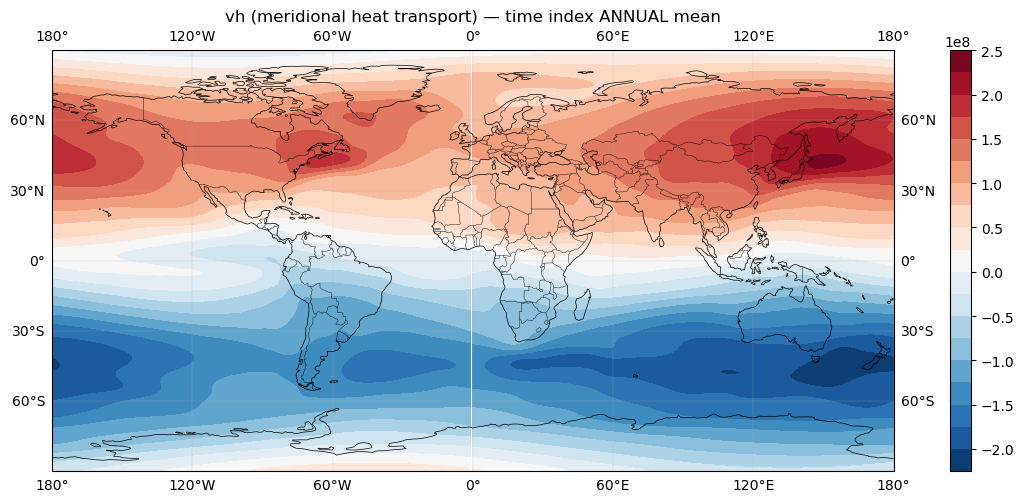

In [16]:
# Select a time index (e.g., month 0 = January)
t = "ANNUAL mean"
u = ds['uh'].mean(dim="time") ;# isel(time=t)
v = ds['vh'].mean(dim="time") ;# isel(time=t)

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(ds.longitude, ds.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title(f'vh (meridional heat transport) — time index {t}')
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


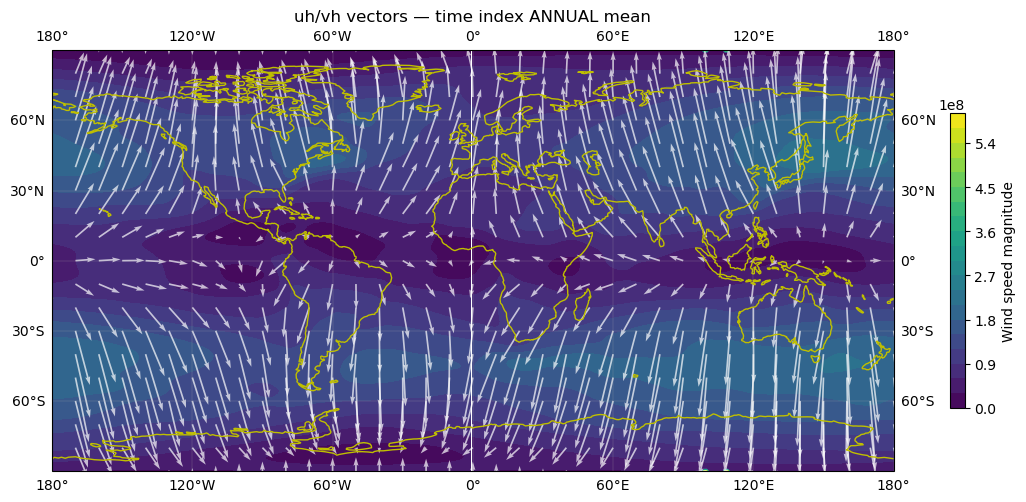

In [15]:
# --- Plot 2: u + v wind vectors ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color='y')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Speed for background shading
speed = np.sqrt(u**2 + v**2)
im = ax.contourf(ds.longitude, ds.latitude, speed,
                 levels=20, cmap='viridis', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Wind speed magnitude', shrink=0.7)

# Quiver — subsample to avoid clutter
skip = 10
ax.quiver(ds.longitude[::skip], ds.latitude[::skip],
          u[::skip, ::skip], v[::skip, ::skip],
          transform=ccrs.PlateCarree(), scale=5e8*5, width=0.002, color='white', alpha=0.7)

ax.set_title(f'uh/vh vectors — time index {t}')
plt.tight_layout()
# plt.savefig('uv_vectors.png', dpi=150)
plt.show()
